# Exploration of Specific Categories within the Taxonomy

see also https://github.com/openfoodfacts/openfoodfacts-python/blob/develop/docs/handle_taxonomies.md

In [1]:
from IPython.display import Image
from openfoodfacts.taxonomy import get_taxonomy, Taxonomy
from networkx.drawing.nx_pydot import to_pydot
import networkx as nx
import pandas as pd
import pydot

## Load Category Taxonomy

In [2]:
categories: Taxonomy = get_taxonomy("category", download_newer=True)
print(f"{len(categories):,} categories")

14,180 categories


In [3]:
G = nx.DiGraph();


for node in categories.iter_nodes():
  # ignore non-English categories
  if not node.id.startswith('en:'):
    continue

  for parent in node.parents:
    if not parent.id.startswith('en:'):
      print(f"parent {parent.id} of {node.id} is not in English")
      continue
  
    G.add_edge(parent.id.replace(':', '.'), node.id.replace(':', '.'))

print(f"#Nodes: {len(G.nodes):,}")
print(f"#Edges: {len(G.edges):,}")

parent fr:gateaux-de-semoule of en:canned-semolina-puddings is not in English
parent fr:charcuteries-diverses of en:galantine is not in English
parent nl:sinterklaasproducten of en:chocolate-letters is not in English
parent fr:biscuits-fourres-aux-fruits of en:fruit-biscuits-with-reduced-fat is not in English
parent fr:diots of en:sausage-from-savoy is not in English
parent de:obstbrand of en:portuguese-fruit-spirit is not in English
parent xx:liverwurst of en:liverwurst-spreads is not in English
parent fr:pains-de-tradition-francaise of en:french-bread-multigrain-from-bakery is not in English
parent fr:sauces-au-soja-sucrees of en:tare-sauces is not in English
parent fr:fondues of en:cheese-fondue-from-savoy is not in English
parent de:obstbrand of en:german-fruit-spirit is not in English
parent ca:cervesa-ipa of en:triple-ipa is not in English
parent fr:quenelles of en:veal-quenelles is not in English
parent de:obstbrand of en:romanian-fruit-spirit is not in English
parent fr:farines

In [4]:
categories['en:sweet-spreads'].children

[<TaxonomyNode en:honey-based-preparations>,
 <TaxonomyNode en:flower-preserves>,
 <TaxonomyNode en:beer-spreads>,
 <TaxonomyNode en:confectionary-based-spreads>,
 <TaxonomyNode fr:cremes-de-pistaches>,
 <TaxonomyNode en:hazelnut-spreads>,
 <TaxonomyNode en:thick-syrups>,
 <TaxonomyNode en:almond-spreads>,
 <TaxonomyNode fr:pates-a-tartiner>,
 <TaxonomyNode en:ginger-preserves>,
 <TaxonomyNode en:honeys>,
 <TaxonomyNode en:caramel-spreads>,
 <TaxonomyNode en:chocolate-spreads>,
 <TaxonomyNode en:carob-spreads>,
 <TaxonomyNode en:speculoos-spreads>,
 <TaxonomyNode en:milk-jams>,
 <TaxonomyNode en:sweet-spread-variety-packs>,
 <TaxonomyNode en:fruit-and-vegetable-preserves>,
 <TaxonomyNode en:wine-spreads>,
 <TaxonomyNode en:fruit-curds>]

In [5]:
G['en.sweet-spreads']

AtlasView({'en.honey-based-preparations': {}, 'en.flower-preserves': {}, 'en.beer-spreads': {}, 'en.confectionary-based-spreads': {}, 'en.hazelnut-spreads': {}, 'en.thick-syrups': {}, 'en.almond-spreads': {}, 'en.ginger-preserves': {}, 'en.honeys': {}, 'en.caramel-spreads': {}, 'en.chocolate-spreads': {}, 'en.carob-spreads': {}, 'en.speculoos-spreads': {}, 'en.milk-jams': {}, 'en.sweet-spread-variety-packs': {}, 'en.fruit-and-vegetable-preserves': {}, 'en.wine-spreads': {}, 'en.fruit-curds': {}})

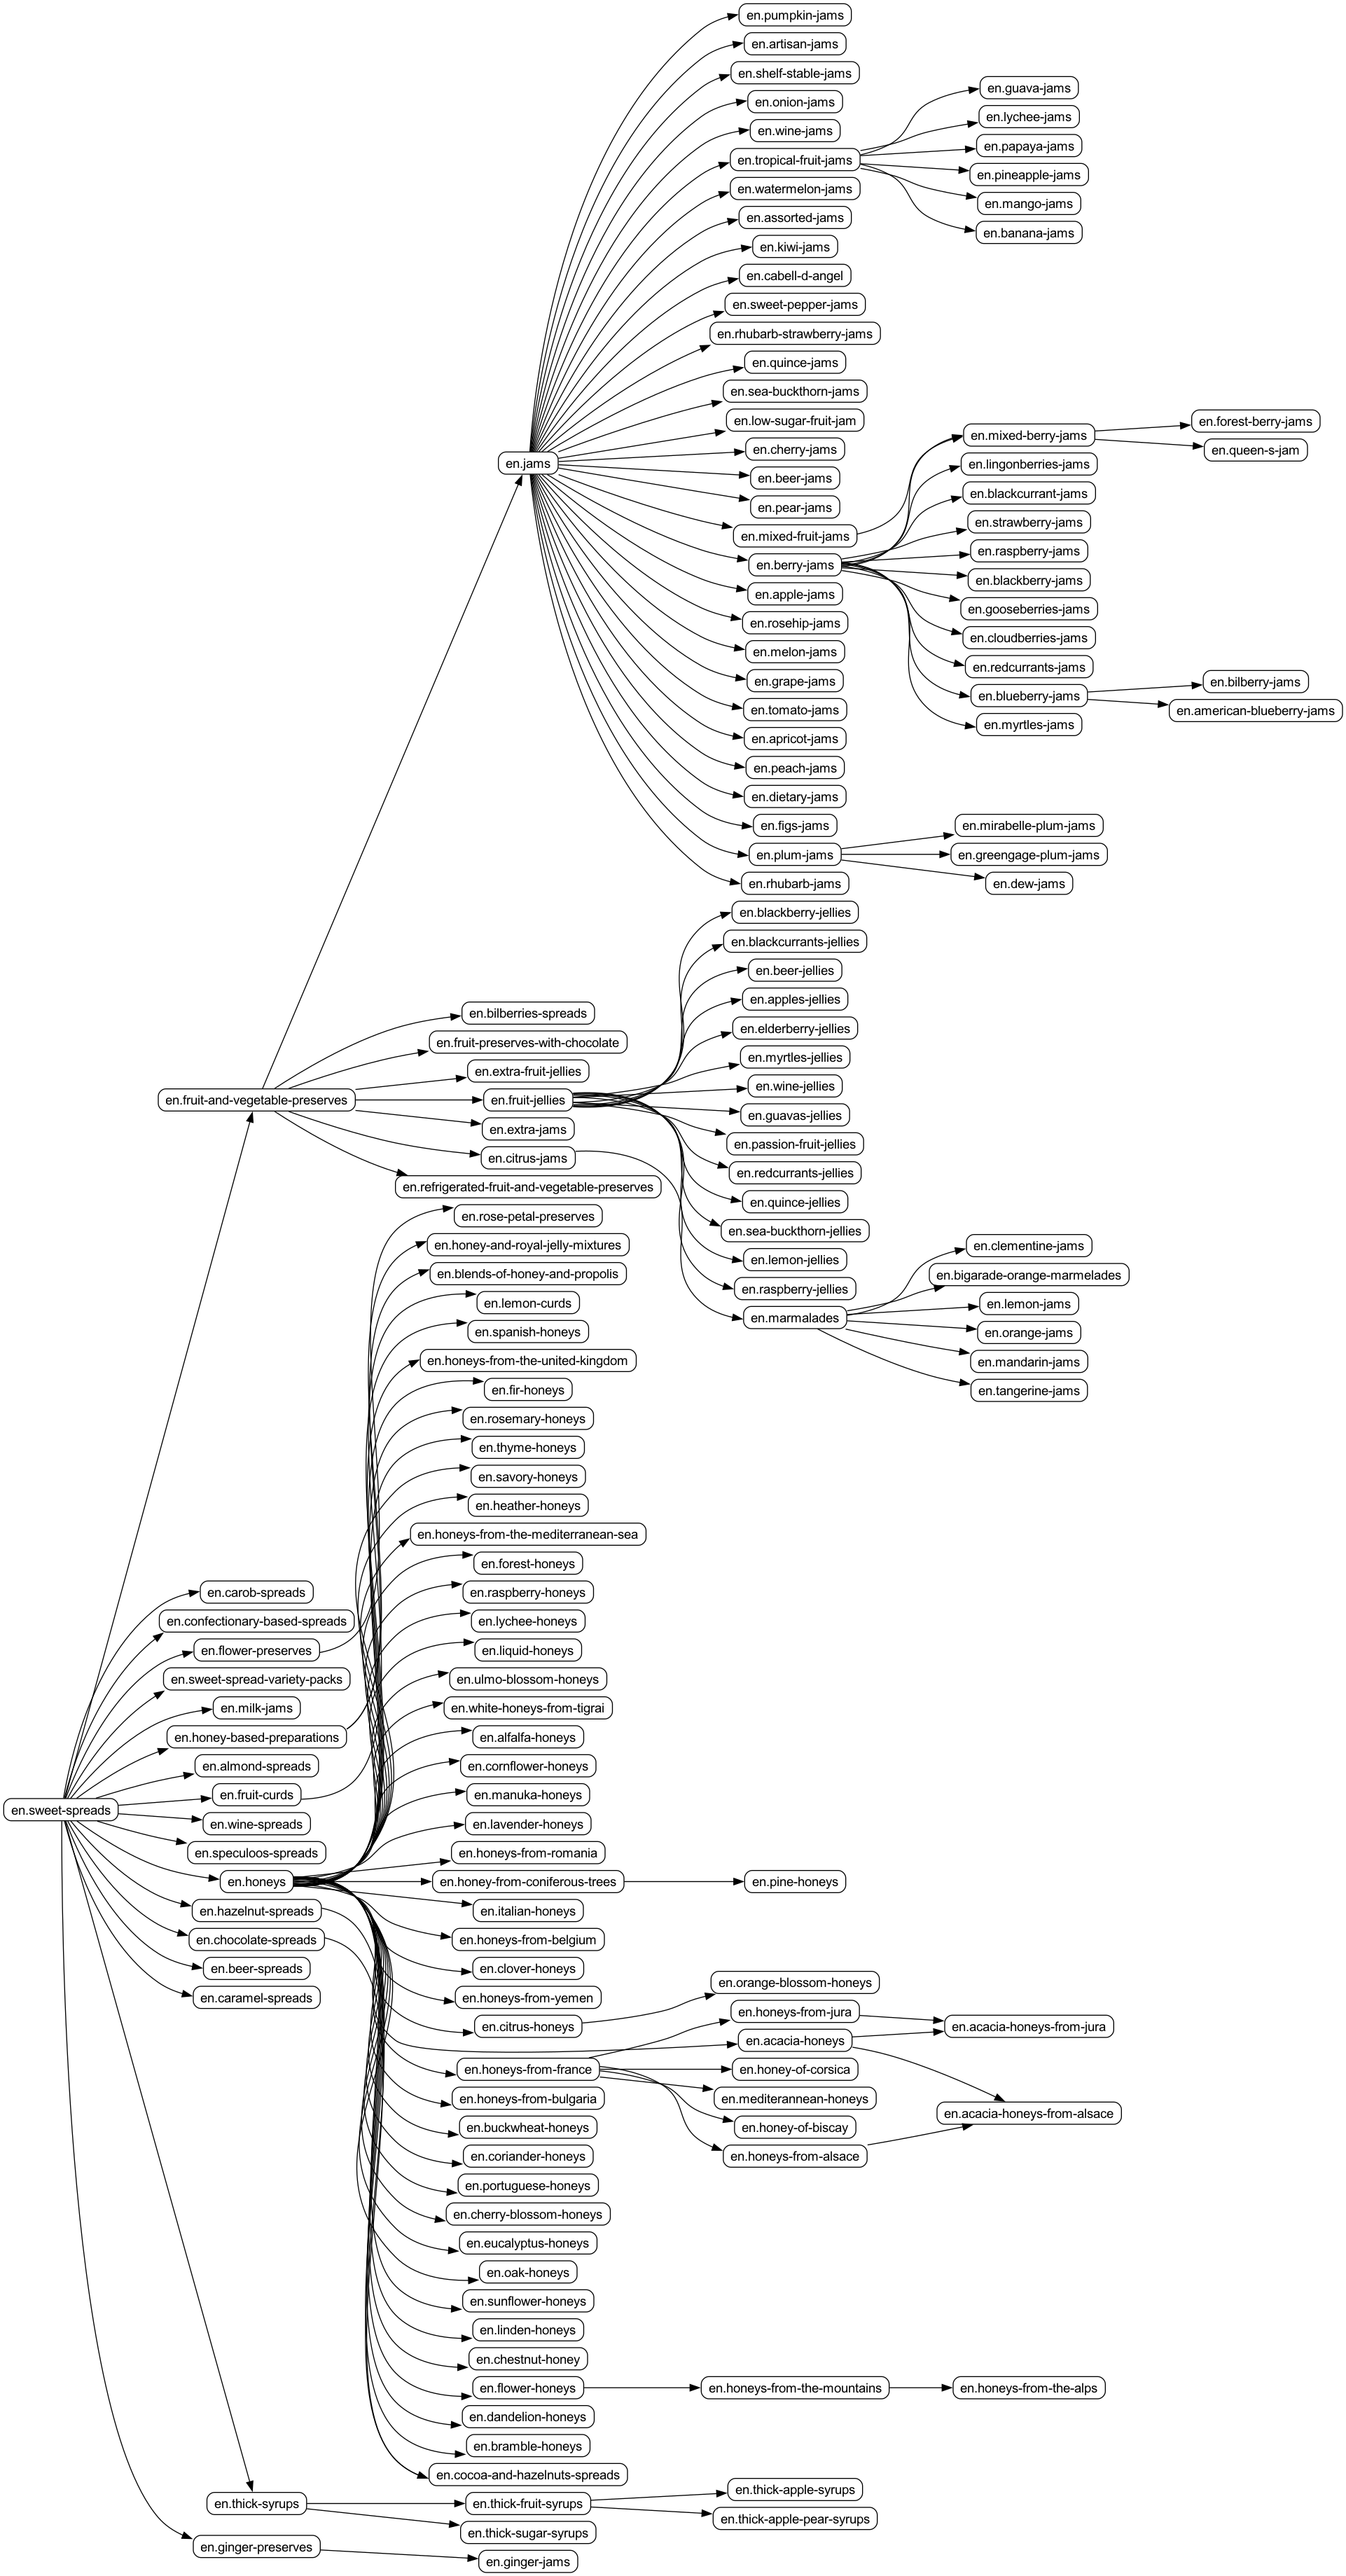

In [6]:
cat_name = 'en.sweet-spreads'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

Image(P.create_png())

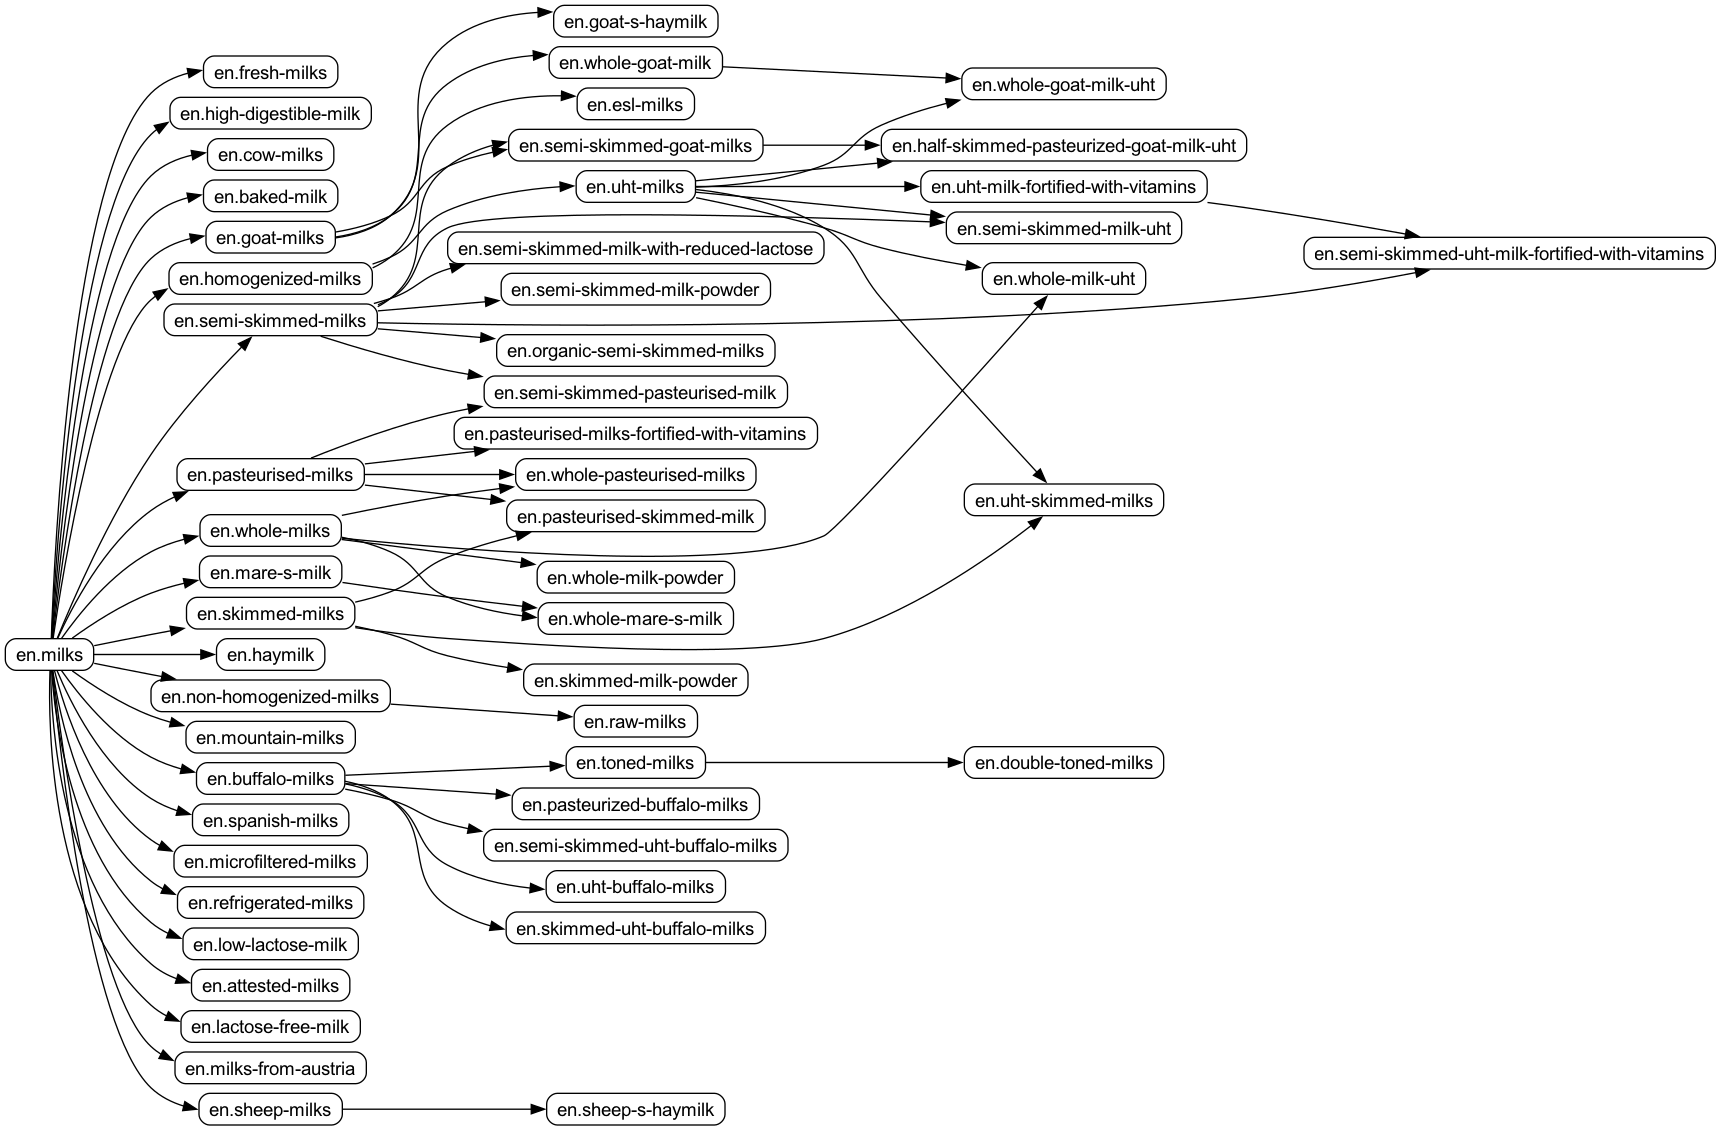

In [7]:
cat_name = 'en.milks'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

Image(P.create_png())

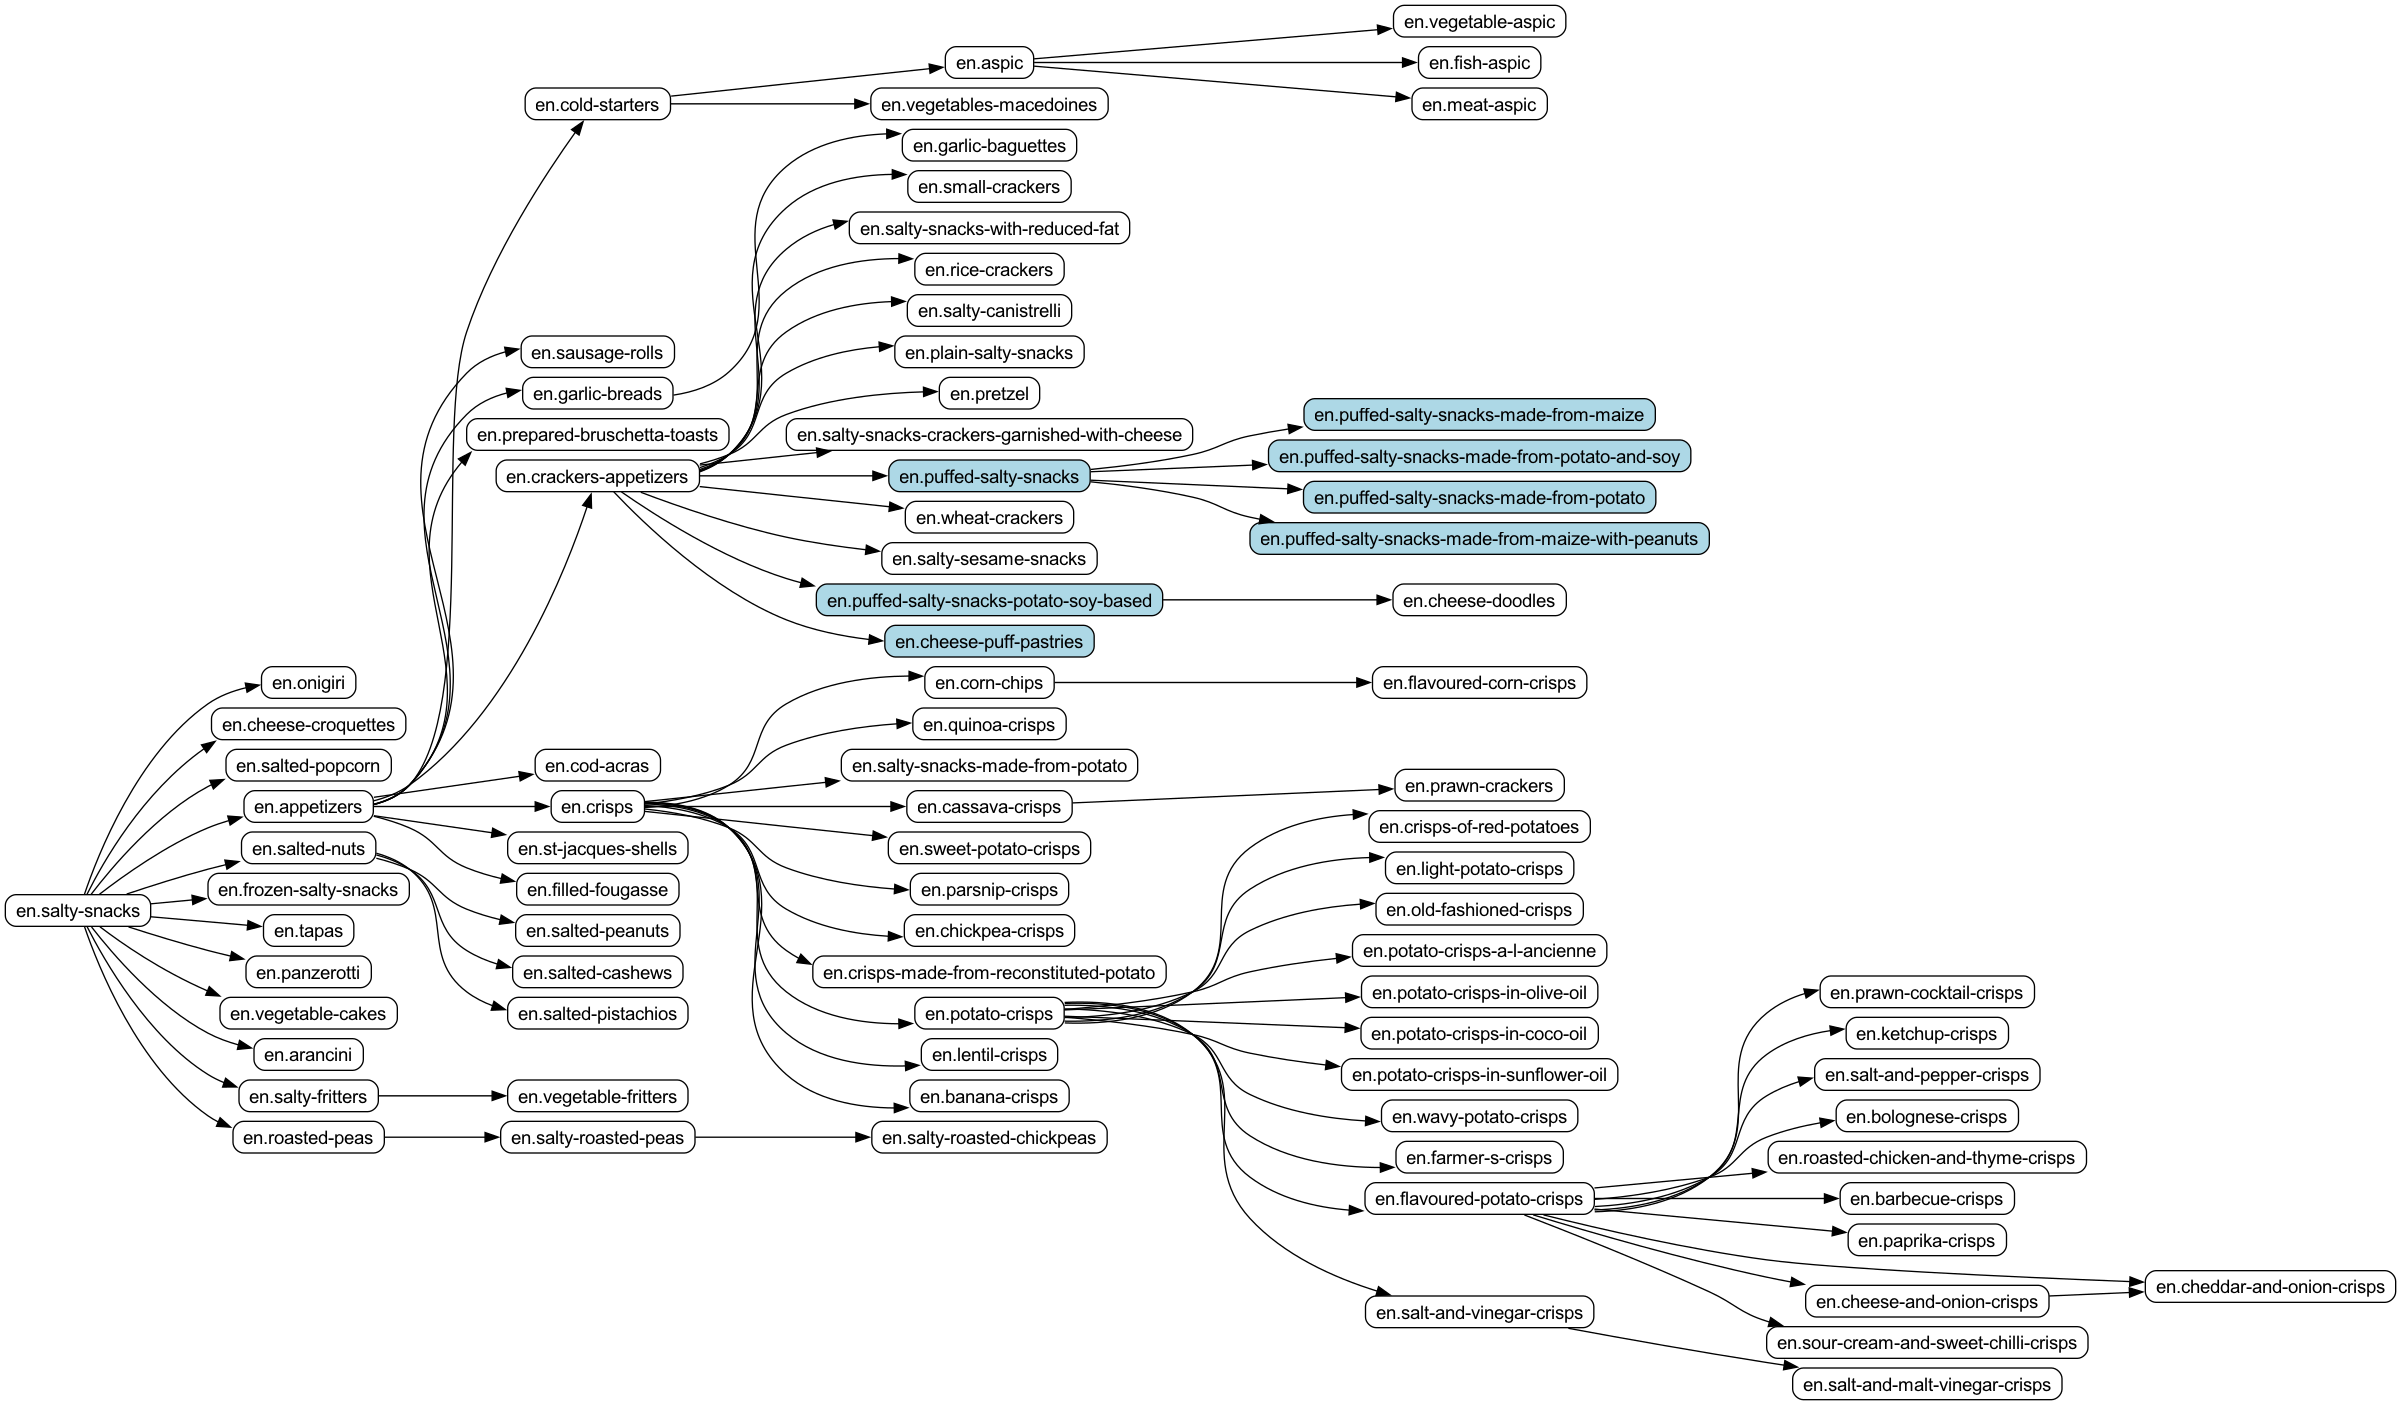

In [8]:
cat_name = 'en.salty-snacks'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

    color = 'lightblue' if 'puff' in node.get_name() else 'white'
    node.set_style("rounded,filled")
    node.set('fillcolor', color)

#P.set_node_defaults(shape='box', style="rounded,filled")

P.write_png('salty-snacks.png')

Image(P.create_png())

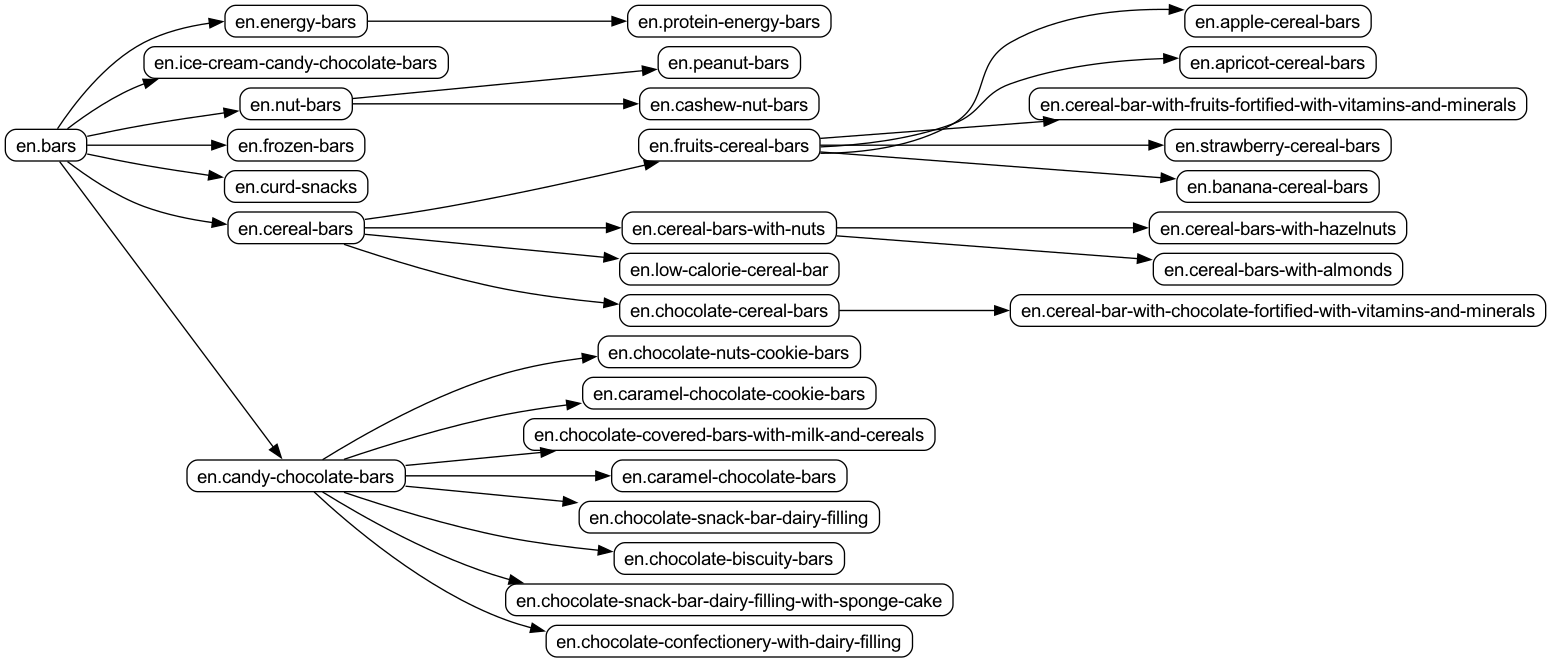

In [9]:
cat_name = 'en.bars'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

Image(P.create_png())